<a href="https://colab.research.google.com/github/Pranav-Trivedi20/Student-Mental-Health-Early-Warning-System/blob/main/Dataset_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install sdv

import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# 1. Load your 40 real responses
real_data = pd.read_csv("/content/drive/MyDrive/Student Mental Health Project/seed_responses.csv")

# 2. Auto-detect metadata (column types: categorical, numerical, etc.)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)
# Manually fix any misdetected types, e.g.:
# metadata.update_column(column_name='gender', sdtype='categorical')

# 3. Fit the copula model on your seed data
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

# 4. Generate as many synthetic rows as you need
synthetic_data = synthesizer.sample(num_rows=500)
synthetic_data.to_csv("/content/drive/MyDrive/Student Mental Health Project/synthetic_responses.csv", index=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.9/259.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.0 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [2]:
import sdv
print(sdv.__version__)

1.38.5


In [9]:
from sdv.metadata import Metadata
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# 1. Detect metadata using the new unified class (wrap your table in a dict)
metadata = Metadata.detect_from_dataframes(data={'responses': real_data})

# 2. Fit synthesizer — works the same with the new Metadata object
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

# 3. Sample
synthetic_data = synthesizer.sample(num_rows=600)

# 4. Evaluate — now compatible
diagnostic = run_diagnostic(real_data, synthetic_data, metadata)
quality_report = evaluate_quality(real_data, synthetic_data, metadata)
quality_report.get_details('Column Shapes')
quality_report.get_details('Column Pair Trends')

/tmp/ipykernel_1654/1740225869.py:3: FutureWarning: The evaluation functions are now accessible via the 'sdv.evaluation' module.
  from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generating report ...

(1/4) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 280.74it/s]|
Data Validity Score: 100.0%

(2/4) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 73.75it/s]|
Data Structure Score: 100.0%

(3/4) Evaluating Relationship Validity: N/A
This property does not apply to single-table data.

(4/4) Evaluating Constraint Validity: N/A
No constraints were provided.

Overall Score (Average): 100.0%

Generating report ...

(1/4) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 666.41it/s]|
Column Shapes Score: 90.85%

(2/4) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 93.10it/s]|
Column Pair Trends Score: 70.42%

(3/4) Evaluating Cardinality: N/A
This property does not apply to single-table data.

(4/4) Evaluating Intertable Trends: N/A
This property does not apply to single-table data.

Overall Score (Average): 80.64%



,Table,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,responses,Age,Year,ContingencySimilarity,0.456667,NaN,NaN,0.721978,True
1,responses,Age,"On average, how many hours do you sleep per ...",ContingencySimilarity,0.581667,NaN,NaN,0.396196,True
2,responses,Age,How many hours per day do you spend on scree...,ContingencySimilarity,0.595000,NaN,NaN,0.480484,True
3,responses,Age,"How often have you felt nervous, anxious, or...",ContingencySimilarity,0.558333,NaN,NaN,0.449374,True
4,responses,Age,How often have you had trouble relaxing?,ContingencySimilarity,0.531667,NaN,NaN,0.532943,True
...,...,...,...,...,...,...,...,...,...
61,responses,How often have you had trouble concentrating o...,How often have you felt confident about hand...,ContingencySimilarity,NaN,NaN,NaN,0.274814,False
62,responses,How often have you had trouble concentrating o...,How would you rate your current class attendan...,ContingencySimilarity,0.755000,NaN,NaN,0.365834,True
63,responses,How often have you felt unable to control impo...,How often have you felt confident about hand...,ContingencySimilarity,0.628333,NaN,NaN,0.451601,True
64,responses,How often have you felt unable to control impo...,How would you rate your current class attendan...,ContingencySimilarity,0.733333,NaN,NaN,0.360762,True


#Quality Score

In [10]:
print(f"Overall Quality Score: {quality_report.get_score()*100:.2f}%")
quality_report.get_properties()

Overall Quality Score: 80.64%


,Property,Score
0,Column Shapes,0.908472
1,Column Pair Trends,0.704231


#Side-by-side summary stats

In [11]:
import pandas as pd
comparison = pd.DataFrame({
    'Real Mean': real_data.mean(numeric_only=True),
    'Synthetic Mean': synthetic_data.mean(numeric_only=True),
    'Real Std': real_data.std(numeric_only=True),
    'Synthetic Std': synthetic_data.std(numeric_only=True)
})
comparison

,Real Mean,Synthetic Mean,Real Std,Synthetic Std
Age,19.900,20.243333,1.549193,1.866350
Year,2.475,2.468333,0.960435,0.898337


#Correlation heatmap overlay

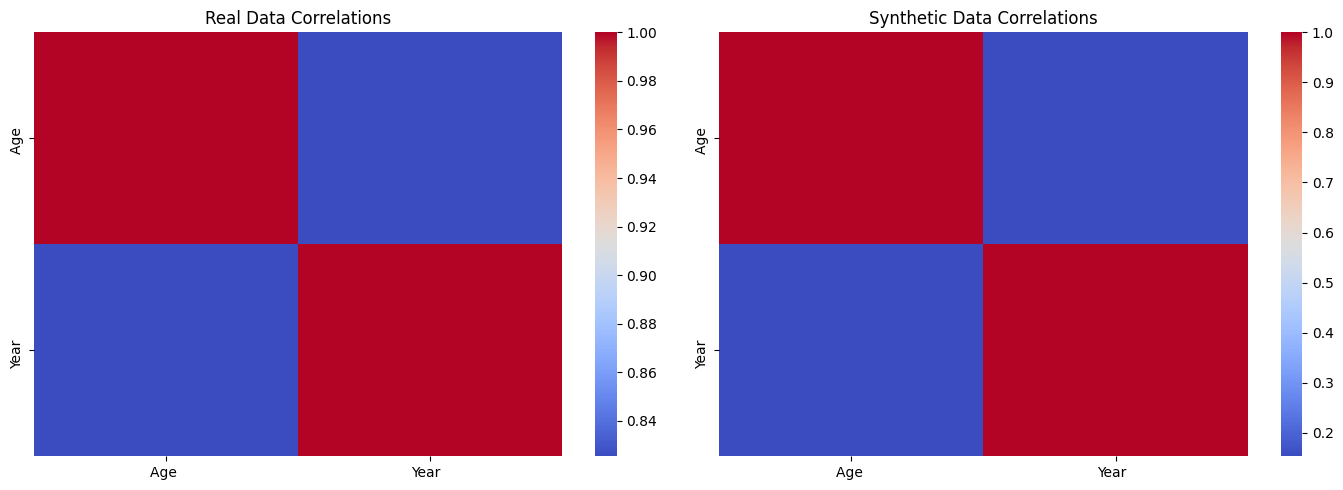

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(real_data.corr(numeric_only=True), ax=axes[0], cmap='coolwarm', annot=False)
axes[0].set_title("Real Data Correlations")
sns.heatmap(synthetic_data.corr(numeric_only=True), ax=axes[1], cmap='coolwarm', annot=False)
axes[1].set_title("Synthetic Data Correlations")
plt.tight_layout()
plt.savefig("correlation_comparison.png", dpi=150)
plt.show()

#PCA scatter

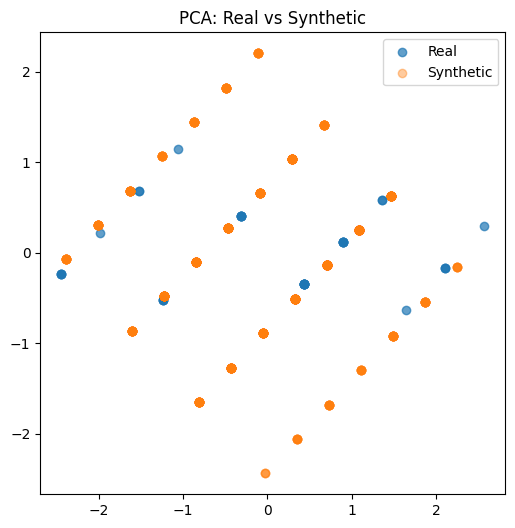

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_cols = real_data.select_dtypes(include='number').columns
X_real = StandardScaler().fit_transform(real_data[num_cols])
X_syn = StandardScaler().fit_transform(synthetic_data[num_cols])

pca = PCA(n_components=2).fit(X_real)
real_pca, syn_pca = pca.transform(X_real), pca.transform(X_syn)

plt.figure(figsize=(6,6))
plt.scatter(real_pca[:,0], real_pca[:,1], label='Real', alpha=0.7)
plt.scatter(syn_pca[:,0], syn_pca[:,1], label='Synthetic', alpha=0.4)
plt.legend(); plt.title("PCA: Real vs Synthetic")
plt.savefig("pca_comparison.png", dpi=150)
plt.show()

In [14]:
synthetic_data.to_csv("synthetic_responses_500.csv", index=False)
print(f"Seed: {len(real_data)} real responses → Generated: {len(synthetic_data)} synthetic responses")
print(f"Quality Score: {quality_report.get_score()*100:.2f}%")

Seed: 40 real responses → Generated: 600 synthetic responses
Quality Score: 80.64%
